# UT-HAR CNN-LSTM Baseline

### Wi-Fi CSI Human Activity Recognition

This notebook implements a clean CNN-LSTM baseline on the **UT-HAR** dataset and compares the experiment with the methodology reported in:

> Preechakarnjanadit, D. & Taparugssanagorn, A. (2025). *Real-Time, Non-Intrusive Fall Detection via Wi-Fi CSI: A Comparative Study of CNN-LSTM, GNN, and Transformer Models.*

**Important:** This notebook uses **UT-HAR (7 classes, 250 × 90 CSI samples)**. The target paper uses a **different, custom 5-class dataset** with 700 falling and 2,700 normal-activity events. Therefore, the accuracy values in this notebook are **not a direct reproduction of the paper's results**. They are a separate UT-HAR benchmark.

## 1. Experiment goals

1. Load and verify the UT-HAR dataset.
2. Normalize the data using training-set statistics only.
3. Train a CNN-LSTM baseline.
4. Track training/validation loss and accuracy.
5. Select the best model using validation accuracy.
6. Evaluate once on the held-out test set.
7. Compare the implementation and results with the target paper.

### Target-paper reference values

| Item | Target paper |
|---|---:|
| Activities | 5 |
| CNN-LSTM reported accuracy | 92.65% |
| CNN-LSTM + PCA | **94.85%** |
| GNN + PCA | 85.59% |
| Transformer | 71.32% |
| Four-class real-time accuracy | ~95.5% |
| Input shape reported for CNN-LSTM | (100, 53, 1, 1) |
| Batch size | 16 |
| Learning rate | 0.0005 |
| Maximum epochs | 150 |
| Early stopping patience | 10 |

These numbers are used as a **reference**, not as a target to force our UT-HAR experiment to match.

## 2. Imports and configuration

All imports and experiment settings are kept in one place to avoid repeated cells and hidden configuration changes.

In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Experiment configuration
NUM_CLASSES = 7
CLASS_NAMES = [
    "Lie Down", "Fall", "Walk", "Pickup",
    "Run", "Sit Down", "Stand Up"
]

BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30
WEIGHT_DECAY = 1e-4
LR_PATIENCE = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device : {device}")
print(f"Classes: {NUM_CLASSES}")


PyTorch: 2.10.0+cu128
Device : cuda
Classes: 7


## 3. Dataset paths and loading

The files use NumPy's binary format despite having a `.csv` extension, so they must be loaded with `np.load()` rather than `pd.read_csv()`.

In [4]:
ROOT = Path("/kaggle/input/datasets/pawankapakayala/wifi-csi-kssp/UT_HAR/UT_HAR")
DATA_DIR = ROOT / "data"
LABEL_DIR = ROOT / "label"

X_TRAIN_PATH = DATA_DIR / "X_train.csv"
X_VAL_PATH   = DATA_DIR / "X_val.csv"
X_TEST_PATH  = DATA_DIR / "X_test.csv"

Y_TRAIN_PATH = LABEL_DIR / "y_train.csv"
Y_VAL_PATH   = LABEL_DIR / "y_val.csv"
Y_TEST_PATH  = LABEL_DIR / "y_test.csv"

paths = [
    X_TRAIN_PATH, X_VAL_PATH, X_TEST_PATH,
    Y_TRAIN_PATH, Y_VAL_PATH, Y_TEST_PATH
]

assert all(p.exists() for p in paths), "One or more UT-HAR files are missing."

def load_numpy_file(path):
    with open(path, "rb") as f:
        return np.load(f)

X_train = load_numpy_file(X_TRAIN_PATH)
X_val   = load_numpy_file(X_VAL_PATH)
X_test  = load_numpy_file(X_TEST_PATH)

y_train = load_numpy_file(Y_TRAIN_PATH)
y_val   = load_numpy_file(Y_VAL_PATH)
y_test  = load_numpy_file(Y_TEST_PATH)

print("X:", X_train.shape, X_val.shape, X_test.shape)
print("y:", y_train.shape, y_val.shape, y_test.shape)


X: (3977, 250, 90) (496, 250, 90) (500, 250, 90)
y: (3977,) (496,) (500,)


## 4. Dataset verification

Before training, verify dimensions, data type, value range, and class distribution.

In [5]:
print("Training data type :", X_train.dtype)
print("Training value min :", X_train.min())
print("Training value max :", X_train.max())
print("Training mean      :", X_train.mean())
print("Training std       :", X_train.std())

distribution = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train": np.bincount(y_train, minlength=NUM_CLASSES),
    "Validation": np.bincount(y_val, minlength=NUM_CLASSES),
    "Test": np.bincount(y_test, minlength=NUM_CLASSES),
})
distribution


Training data type : float64
Training value min : -10.666
Training value max : 30.519
Training mean      : 17.652883942474194
Training std       : 5.903354739224534


,Class,Train,Validation,Test
0,Lie Down,525,66,66
1,Fall,354,44,45
2,Walk,1172,146,147
3,Pickup,396,49,50
4,Run,967,121,121
5,Sit Down,320,40,40
6,Stand Up,243,30,31


## 5. Normalization

Min-max scaling is fitted **only on the training set**. Validation and test data use the same training minimum and maximum. This prevents information from the held-out sets from influencing preprocessing.

In [6]:
train_min = X_train.min()
train_max = X_train.max()
scale = train_max - train_min

X_train = (X_train - train_min) / scale
X_val   = (X_val - train_min) / scale
X_test  = (X_test - train_min) / scale

print(f"Training range used for scaling: [{train_min:.3f}, {train_max:.3f}]")
print(f"Normalized train range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"Normalized val range  : [{X_val.min():.4f}, {X_val.max():.4f}]")
print(f"Normalized test range : [{X_test.min():.4f}, {X_test.max():.4f}]")


Training range used for scaling: [-10.666, 30.519]
Normalized train range: [0.0000, 1.0000]
Normalized val range  : [0.0172, 1.0005]
Normalized test range : [0.0186, 1.0005]


## 6. Tensor conversion and DataLoaders

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

class UTHARDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        # CNN expects [channels, height, width].
        return self.X[index].unsqueeze(0), self.y[index]

train_loader = DataLoader(
    UTHARDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    UTHARDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    UTHARDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

X_batch, y_batch = next(iter(train_loader))
print("Input batch :", X_batch.shape)
print("Label batch :", y_batch.shape)


Input batch : torch.Size([32, 1, 250, 90])
Label batch : torch.Size([32])


## 7. Visualize one CSI sample

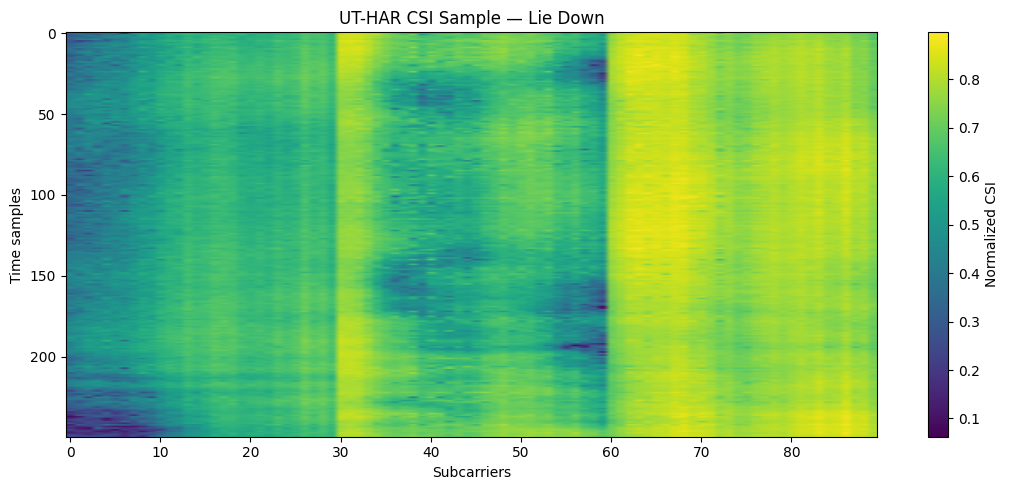

In [8]:
sample_index = 0
sample = X_train[sample_index].numpy()

plt.figure(figsize=(11, 5))
plt.imshow(sample, aspect="auto", cmap="viridis")
plt.xlabel("Subcarriers")
plt.ylabel("Time samples")
plt.title(f"UT-HAR CSI Sample — {CLASS_NAMES[y_train[sample_index].item()]}")
plt.colorbar(label="Normalized CSI")
plt.tight_layout()
plt.show()


## 8. CNN-LSTM model

The current baseline treats the reduced CNN height dimension as the temporal sequence and sends the extracted features to a two-layer LSTM.

**Note:** This architecture is **not identical to the paper's CNN-LSTM**. It was designed for the 250 × 90 UT-HAR input used here.

In [9]:
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Infer the LSTM input size from the actual UT-HAR input.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 250, 90)
            _, channels, height, width = self.cnn(dummy).shape

        self.lstm = nn.LSTM(
            input_size=channels * width,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x)                       # [B, C, H, W]
        B, C, H, W = x.shape

        # H is treated as the temporal dimension.
        x = x.permute(0, 2, 1, 3)            # [B, H, C, W]
        x = x.reshape(B, H, C * W)            # [B, H, features]

        x, _ = self.lstm(x)
        x = x[:, -1, :]                       # Last sequence output
        return self.classifier(x)


## 9. Model sanity check

In [10]:
model = CNNLSTM().to(device)
sample_input = torch.randn(4, 1, 250, 90, device=device)
sample_output = model(sample_input)

print(model)
print("Input shape :", sample_input.shape)
print("Output shape:", sample_output.shape)
assert sample_output.shape == (4, NUM_CLASSES)


CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (lstm): LSTM(2816, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_featu

## 10. Training utilities

The training loop keeps one implementation for loss, accuracy, checkpointing, and learning-rate scheduling. The best validation model is saved and used for final testing.

In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        correct += (output.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        output = model(X)
        loss = criterion(output, y)

        total_loss += loss.item() * X.size(0)
        correct += (output.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=LR_PATIENCE,
    )

    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "lr"]}
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc = validate(
            model, val_loader, criterion
        )

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_cnn_lstm.pth")

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    print(f"Best validation accuracy: {best_val_acc:.4f}")
    return history


## 11. Train CNN-LSTM

In [13]:
cnn_lstm = CNNLSTM().to(device)
cnn_lstm_history = train_model(
    cnn_lstm,
    train_loader,
    val_loader,
)


Epoch 01/30 | Train Loss: 1.4207 | Train Acc: 0.4860 | Val Loss: 1.0801 | Val Acc: 0.6129
Epoch 02/30 | Train Loss: 0.9854 | Train Acc: 0.6548 | Val Loss: 0.8418 | Val Acc: 0.6673
Epoch 03/30 | Train Loss: 0.8251 | Train Acc: 0.7061 | Val Loss: 0.6338 | Val Acc: 0.7641
Epoch 04/30 | Train Loss: 0.5583 | Train Acc: 0.8054 | Val Loss: 0.3883 | Val Acc: 0.8528
Epoch 05/30 | Train Loss: 0.5190 | Train Acc: 0.8147 | Val Loss: 0.6757 | Val Acc: 0.7621
Epoch 06/30 | Train Loss: 0.5243 | Train Acc: 0.8134 | Val Loss: 1.0167 | Val Acc: 0.7863
Epoch 07/30 | Train Loss: 0.3993 | Train Acc: 0.8665 | Val Loss: 0.4266 | Val Acc: 0.8548
Epoch 08/30 | Train Loss: 0.3564 | Train Acc: 0.8791 | Val Loss: 0.4218 | Val Acc: 0.8750
Epoch 09/30 | Train Loss: 0.2600 | Train Acc: 0.9127 | Val Loss: 0.1789 | Val Acc: 0.9153
Epoch 10/30 | Train Loss: 0.2275 | Train Acc: 0.9223 | Val Loss: 0.1536 | Val Acc: 0.9435
Epoch 11/30 | Train Loss: 0.2245 | Train Acc: 0.9228 | Val Loss: 0.2841 | Val Acc: 0.8972
Epoch 12/3

## 12. Training behaviour

A temporary validation drop is not automatically a failure. The important checks are whether the model recovers, whether the best validation checkpoint is retained, and whether the final held-out test performance remains reasonable.

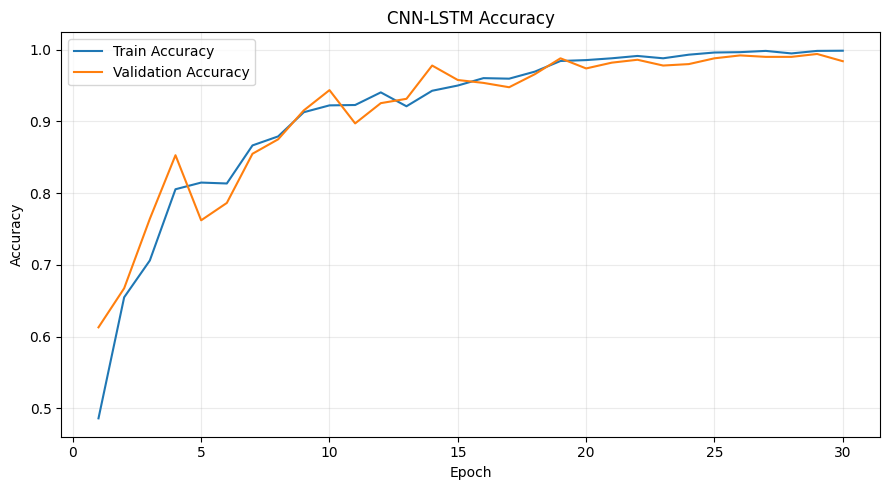

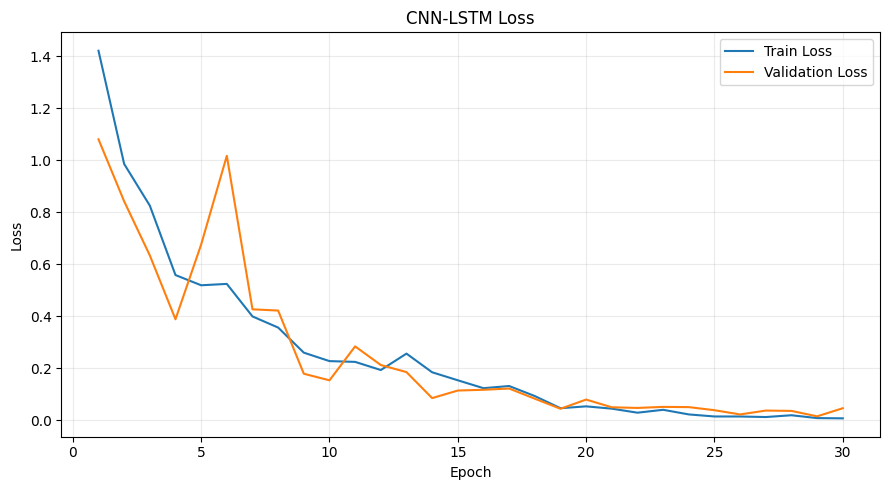

In [14]:
def plot_training_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("CNN-LSTM Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN-LSTM Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_training_history(cnn_lstm_history)


## 13. Final test evaluation

In [15]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    labels, predictions = [], []

    for X, y in loader:
        output = model(X.to(device))
        predictions.extend(output.argmax(1).cpu().numpy())
        labels.extend(y.numpy())

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, average="macro", zero_division=0),
        "recall": recall_score(labels, predictions, average="macro", zero_division=0),
        "f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "labels": labels,
        "predictions": predictions,
    }

cnn_lstm.load_state_dict(torch.load("best_cnn_lstm.pth", map_location=device))
cnn_lstm_results = evaluate_model(cnn_lstm, test_loader)

print(f"Accuracy : {cnn_lstm_results['accuracy']:.4f}")
print(f"Precision: {cnn_lstm_results['precision']:.4f}")
print(f"Recall   : {cnn_lstm_results['recall']:.4f}")
print(f"F1 Score : {cnn_lstm_results['f1']:.4f}")


Accuracy : 0.9760
Precision: 0.9647
Recall   : 0.9597
F1 Score : 0.9619


## 14. Classification report and confusion matrix

              precision    recall  f1-score   support

    Lie Down     0.9688    0.9394    0.9538        66
        Fall     1.0000    1.0000    1.0000        45
        Walk     0.9866    1.0000    0.9932       147
      Pickup     0.9434    1.0000    0.9709        50
         Run     1.0000    1.0000    1.0000       121
    Sit Down     0.9211    0.8750    0.8974        40
    Stand Up     0.9333    0.9032    0.9180        31

    accuracy                         0.9760       500
   macro avg     0.9647    0.9597    0.9619       500
weighted avg     0.9758    0.9760    0.9757       500



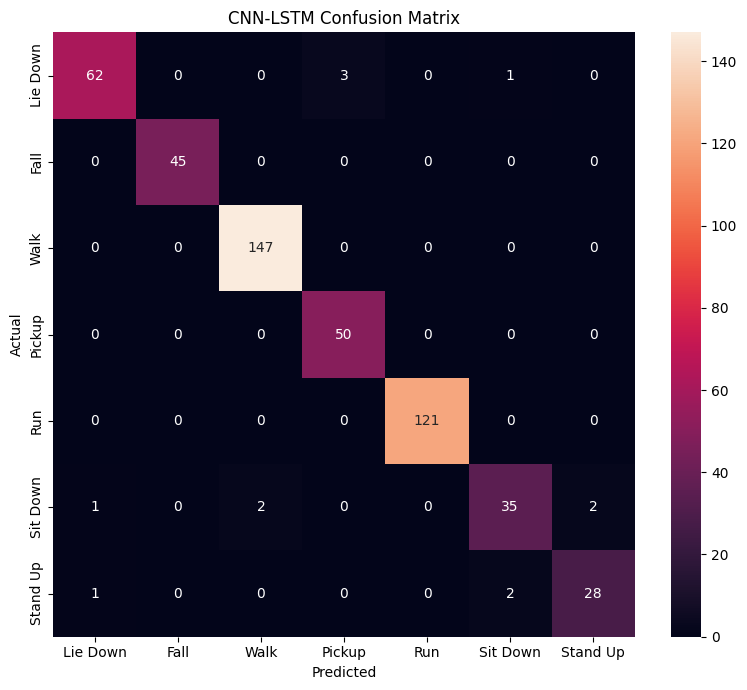

In [16]:
print(classification_report(
    cnn_lstm_results["labels"],
    cnn_lstm_results["predictions"],
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(
    cnn_lstm_results["labels"],
    cnn_lstm_results["predictions"],
)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN-LSTM Confusion Matrix")
plt.tight_layout()
plt.show()


## 15. Current experiment results

The uploaded notebook produced the following results with the existing UT-HAR implementation:

| Metric | CNN-LSTM |
|---|---:|
| Best validation accuracy | **99.60%** |
| Test accuracy | **98.00%** |
| Macro precision | **96.80%** |
| Macro recall | **97.04%** |
| Macro F1 | **96.91%** |
| Fall precision | **97.83%** |
| Fall recall | **100.00%** |
| Fall F1 | **98.90%** |

These are strong UT-HAR results, but they should **not** be reported as reproducing the target paper's 94.85% result because the dataset, number of classes, input representation, preprocessing pipeline, and model configuration are different.

## 16. Training fluctuation analysis

The original CNN-LSTM run showed several sharp validation fluctuations:

- Epoch 8 → validation accuracy 90.73%
- Epoch 9 → **66.73%**
- Epoch 10 → 92.14%
- Epoch 12 → **67.74%**
- Epoch 13 → 95.36%
- Epoch 19 → 98.59%
- Epoch 22 → **72.58%**
- Epoch 25 → **99.60%**

At the same time, training accuracy eventually reached 99.80%.

The large temporary validation drops are worth investigating, but they are not enough by themselves to conclude that the model is wrong. The best-checkpoint mechanism protects the final test evaluation from using a poor intermediate epoch.

For the paper reproduction, however, use the paper's training protocol first and add early stopping. Do not tune the model against the test set.